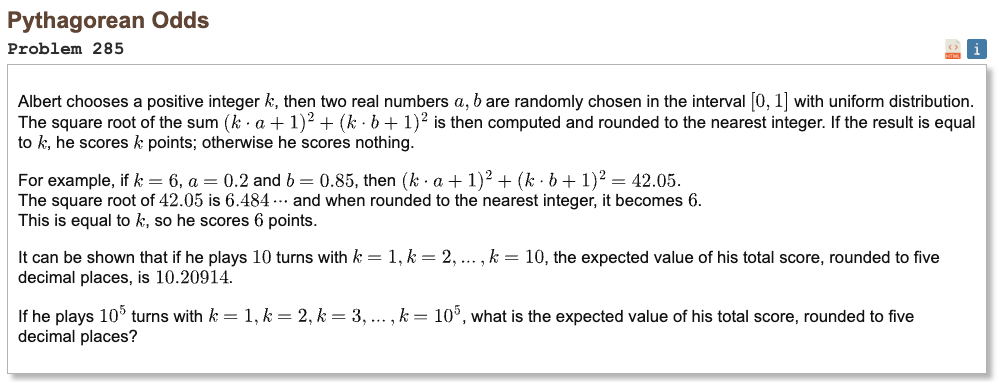

## Initial approach

* divide the whole expression by k, so the random point moves inside a shifted unit square near the point where a quarter circle of radius 1 would sit
* for a fixed k, Albert scores exactly when that point falls inside a very thin ring around radius 1
* so the probability is just an area inside the square, namely the part between two nearby quarter circles
* instead of numeric simulation, compute that area exactly with a circle integral, which is fast and stable enough for all values up to one hundred thousand
* for each radius, split the square into a flat part where the circle fully covers the vertical slice, and a curved part where the arc cuts through the slice
* subtract the inner covered area from the outer covered area to get the scoring probability for that k
* multiply that probability by k, add everything up, and round to five decimal places
* use math because we need square roots and inverse sine for the antiderivative

In [1]:
from math import sqrt, asin

def circle_area_in_shifted_square(radius, k):
    shift = 1.0 / k
    left = shift
    right = min(shift + 1.0, radius)

    if right <= left:
        return 0.0

    full_until = sqrt(max(radius * radius - (shift + 1.0) * (shift + 1.0), 0.0))
    touch_until = sqrt(max(radius * radius - shift * shift, 0.0))

    def integral(x):
        inside = max(radius * radius - x * x, 0.0)
        return 0.5 * (x * sqrt(inside) + radius * radius * asin(x / radius))

    area = 0.0

    a = left
    b = min(right, full_until)
    if b > a:
        area += b - a

    a = max(left, full_until)
    b = min(right, touch_until)
    if b > a:
        area += (integral(b) - integral(a)) - shift * (b - a)

    return area

In [2]:
def solve(limit=100000):
    total = 0.0

    for k in range(1, limit + 1):
        outer = 1.0 + 0.5 / k
        inner = 1.0 - 0.5 / k

        probability = circle_area_in_shifted_square(outer, k) - circle_area_in_shifted_square(inner, k)
        total += k * probability

    return round(total, 5)

In [3]:
%%time
result = solve()
print("Result:", result)

Result: 157055.80972
CPU times: user 223 ms, sys: 1.58 ms, total: 224 ms
Wall time: 224 ms
